In [1]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\ullas gowda bu\OneDrive\Documents\Desktop\nlp project\hotel review data.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

                                              Review Sentiment
0  The room was clean and spacious. Staff were ve...  Positive
1  Excellent food and quick room service. Highly ...  Positive
2  The hotel location was perfect and the rooms w...  Positive
3  Very clean rooms with excellent housekeeping s...  Positive
4  Staff greeted us warmly and the check-in proce...  Positive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     30 non-null     object
 1   Sentiment  30 non-null     object
dtypes: object(2)
memory usage: 612.0+ bytes
None
Review       0
Sentiment    0
dtype: int64


In [3]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

print(df.shape)

(30, 2)


In [4]:
def preprocess(text):
    
    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = text.strip()

    return text

df["Review"] = df["Review"].apply(preprocess)

print(df.head())

                                              Review Sentiment
0  the room was clean and spacious staff were ver...  Positive
1  excellent food and quick room service highly r...  Positive
2  the hotel location was perfect and the rooms w...  Positive
3  very clean rooms with excellent housekeeping s...  Positive
4  staff greeted us warmly and the checkin proces...  Positive


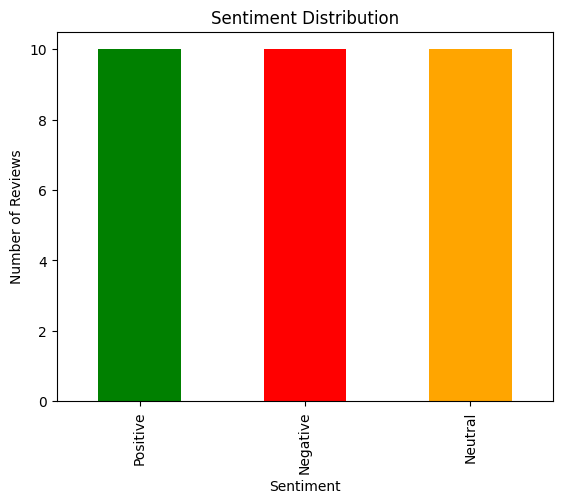

In [5]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["green","red","orange"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [6]:
X = df["Review"]

y = df["Sentiment"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [8]:
tfidf = TfidfVectorizer(stop_words="english")

X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [9]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [10]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [11]:
prediction = model.predict(X_test)

print(prediction)

['Positive' 'Neutral' 'Neutral' 'Positive' 'Neutral' 'Negative']


In [12]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

print()

print(classification_report(y_test, prediction))

print()

print(confusion_matrix(y_test, prediction))

Accuracy : 0.16666666666666666

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       0.33      0.50      0.40         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.17         6
   macro avg       0.11      0.17      0.13         6
weighted avg       0.11      0.17      0.13         6


[[0 1 1]
 [0 1 1]
 [1 1 0]]


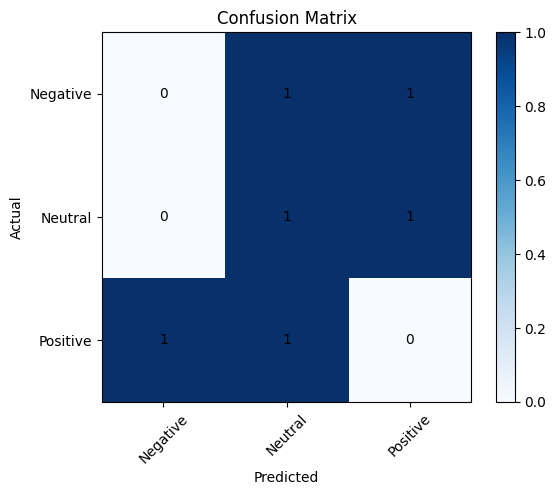

In [13]:
cm = confusion_matrix(y_test, prediction)

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(len(model.classes_)), model.classes_, rotation=45)

plt.yticks(range(len(model.classes_)), model.classes_)

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

In [14]:
new_review = [

    "The room was clean and staff were very friendly."

]

new_review = tfidf.transform(new_review)

result = model.predict(new_review)

print("Predicted Sentiment :", result[0])

Predicted Sentiment : Positive


In [15]:
issues = ["room", "staff", "food", "clean", "wifi", "housekeeping", "bathroom"]

for issue in issues:

    count = df["Review"].str.contains(issue, case=False).sum()

    print(issue, ":", count)

room : 11
staff : 4
food : 5
clean : 5
wifi : 2
housekeeping : 3
bathroom : 2


In [16]:
print("========== Customer Satisfaction Report ==========")

print()

print(df["Sentiment"].value_counts())

print()

print("Positive Reviews :", (df["Sentiment"]=="Positive").sum())

print("Negative Reviews :", (df["Sentiment"]=="Negative").sum())

print("Neutral Reviews :", (df["Sentiment"]=="Neutral").sum())

print()

print("Overall Accuracy :", accuracy)

========== Customer Satisfaction Report ==========

Sentiment
Positive    10
Negative    10
Neutral     10
Name: count, dtype: int64

Positive Reviews : 10
Negative Reviews : 10
Neutral Reviews : 10

Overall Accuracy : 0.16666666666666666
